<a href="https://colab.research.google.com/github/ankitadomadia/AgenticAI/blob/main/Learners_Notebook_Full_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Statement

## Business Context

As organizations grow and scale, they are often inundated with large volumes of data, reports, and documents that contain critical information for decision-making. In real-world business settings, such as venture capital firms like Andreesen Horowitz, business analysts are required to sift through large datasets, research papers, or reports to extract relevant information that impacts strategic decisions.

For instance, consider that you've just joined Andreesen Horowitz, a renowned venture capital firm, and you are tasked with analyzing a dense report like the Harvard Business Review's **"How Apple is Organized for Innovation."** Going through the report manually can be extremely time-consuming as the size and complexity of these report increases. However, by using **Semantic Search** and **Retrieval-Augmented Generation (RAG)** models, you can significantly streamline this process.

Imagine having the capability to directly ask questions like, “How does Apple structure its teams for innovation?” and get immediate, relevant answers drawn from the report. This ability to extract and organize specific insights quickly and accurately enables you to focus on higher-level analysis and decision-making, rather than being bogged down by information retrieval.

## Objective

The goal is to develop a RAG application that helps business analysts efficiently extract key insights from extensive reports, such as “How Apple is Organized for Innovation.”

Specifically, the system aims to:

- Answer user queries by retrieving relevant content directly from lengthy documents.

- Support natural-language interaction without requiring a full manual read-through.

- Act as an intelligent assistant that streamlines the report analysis process.

Through this solution, analysts can save time, improve productivity, and make faster, more informed strategic decisions

## Data Description

**How Apple is Organized for Innovation** - An article of 11 pages in pdf format

## Installing and Importing Necessary Libraries and Dependencies

In [1]:
# Install required libraries
!pip install -q langchain_community==0.3.27 \
              langchain==0.3.27 \
              chromadb==1.0.15 \
              pymupdf==1.26.3 \
              tiktoken==0.9.0 \
              datasets==4.0.0 \
              evaluate==0.4.5 \
              langchain_openai==0.3.30

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.5/19.5 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 90.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 459.1/459.1 kB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 71.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.6/948.6 k

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [14]:
# Import core libraries
import os                                            # Interact with the OS (set environment variables)
import json                                          # Read/write JSON DATA

# Import libraries for working with PDF and OpenAI
from langchain.document_loaders import PyMuPDFLoader   # Load and extract text from PDF files
from openai import OpenAI                            # Access OpenAI model and services

# Import libraries for processing dataframes and text
import tiktoken                                      # Tokenizer used for counting and splitting text for models
import pandas as pd                                  # Load, manipulate and anazlyze tabular data

# Import LangChain components for data loading, chunking, embedding, and vector DBs
from langchain.text_splitter import RecursiveCharacterTextSplitter              # Break text into overlapping chunks for processing
from langchain.embeddings.openai import OpenAIEmbeddings                        # Create vector embeddings using OpenAI's models  # type: ignore
from langchain.vectorstores import Chroma                                       # Store and search vector embeddings using Chroma DB  # type: ignore


from datasets import Dataset                                                    # Used to structure the input (questions, answers, contexts etc.) in tabular format
from langchain_openai import ChatOpenAI                                         # This is needed since LLM is used in metric computation

## Question Answering using LLM

> **Note 1:** When choosing between an open-source Hugging Face (HF) model and OpenAI’s proprietary model, base your decision on your specific needs. If you opt for a Hugging Face model, make sure to connect to a GPU to execute the code efficiently.

> **Note 2**: If the free-tier GPU of Google Colab is not accessible (due to unavailability or exhaustion of daily limit or other reasons), the following steps can be taken:
1. Wait for 12-24 hours until the GPU is accessible again or the daily usage limits are reset.
2. Switch to a different Google account and resume working on the project from there.
3. Try using the CPU runtime:
    - To use the CPU runtime, click on *Runtime* => *Change runtime type* => *CPU* => *Save*
    - One can also click on the *Continue without GPU* option to switch to a CPU runtime (kindly refer to the snapshot below)
    - The instructions for running the code on the CPU are provided in the respective sections of the notebook.

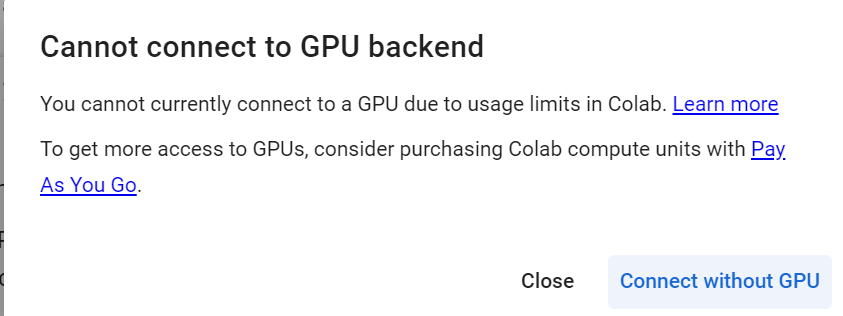

#### Downloading and Loading the model

In [4]:
# Load the JSON file and extract values
file_name = "config.json"                                                       # Name of the configuration file
with open(file_name, 'r') as file:                                              # Open the config file in read mode
    config = json.load(file)                                                    # Load the JSON content as a dictionary
    OPENAI_API_KEY = config.get("OPENAI_API_KEY")                               # Extract the API key from the config
    OPENAI_API_BASE = config.get("OPENAI_API_BASE")                             # Extract the OpenAI base URL from the config

# Store API credentials in environment variables
os.environ['OPENAI_API_KEY'] = OPENAI_API_KEY                                   # Set API key as environment variable
os.environ["OPENAI_BASE_URL"] = OPENAI_API_BASE                                 # Set API base URL as environment variable

# Initialize OpenAI client
client = OpenAI()                                                               # Create an instance of the OpenAI client



#### Defining Response function

In [5]:
# Define a function to get response
def response(user_prompt, max_tokens=1000, temperature=0.3, top_p=0.95):
  # Create a chat completion using the OpenAI client
  completion = client.chat.completions.create(
        model="gpt-4o-mini",                                                    # The model to be used.
        messages=[
            {"role": "user", "content": user_prompt}                            # User prompt is the input/query to respond to
        ],
        max_tokens=max_tokens,                                                  # Max number of tokens to generate in the response
        temperature=temperature,                                                # Controls randomness in the output
        top_p=top_p                                                             # Controls diversity via nucleus sampling
    )
  return completion.choices[0].message.content                                  # Return the text content from the model's reply

### Question 1: Who are the authors of this article and who published this article?

In [6]:
question_1 = "Who are the authors of this article and who published this article?"
base_prompt_response_1=response(question_1)
base_prompt_response_1

"I'm sorry, but I don't have access to external content, including specific articles or their authors. If you provide me with the title or some details about the article, I might be able to help you with general information or context related to the topic."

### Question 2: List down the three leadership characteristics in bulleted points and explain each one of the characteristics under two lines.

In [7]:
question_2 = "List down the three leadership characteristics in bulleted points and explain each one of the characteristics under two lines."
base_prompt_response_2=response(question_2)
base_prompt_response_2

'- **Vision**: A strong leader possesses a clear and compelling vision for the future, inspiring others to work towards common goals and navigate challenges with purpose.\n\n- **Empathy**: Effective leaders demonstrate empathy by understanding and valuing the feelings and perspectives of their team members, fostering a supportive and inclusive environment.\n\n- **Decisiveness**: Good leaders make timely and informed decisions, balancing analysis with intuition, which instills confidence in their team and drives progress.'

### Question 3: Can you explain specific examples from the article where Apple's approach to leadership has led to successful innovations?

In [8]:
question_3 = "Can you explain specific examples from the article where Apple's approach to leadership has led to successful innovations?"
base_prompt_response_3=response(question_3)
base_prompt_response_3

"While I don't have access to specific articles, I can provide a general overview of Apple's approach to leadership and how it has led to successful innovations based on widely known information.\n\n1. **Visionary Leadership**: Under Steve Jobs, Apple cultivated a culture of innovation by emphasizing a clear vision. Jobs focused on creating products that combined technology with design, leading to groundbreaking innovations like the iPod, iPhone, and iPad. His leadership style encouraged teams to think differently and push boundaries.\n\n2. **Cross-Functional Collaboration**: Apple’s leadership promotes collaboration across different departments. For example, the development of the Apple Watch involved input from hardware, software, and health experts, resulting in a product that seamlessly integrates technology with health monitoring.\n\n3. **User-Centric Design**: Apple's leadership prioritizes user experience, which has been a key factor in its innovation strategy. The development o

## Observations
Question 1: The model is responding that it doesn't have any information. It doesn't have access to external content or any specific details to provide more content.

Question2: Output is a very generic answer and has listed characteristics.

Question3: Output provided a general overview of Apple's approach to leadership and how it led to successful innovations.

### Defining the function to Generate a Response From the LLM

In [9]:
system_prompt = """
You are an AI assistant developed for a venture capital firm to support business analysts in analyzing large volumes of strategic documents, reports and research papers.

Your primary goal is to streamline the business review process by:
- Extracting accurate and concise summaries from business reports
- Identifying key metadata such as authors, leadership principles
- Highlighting emerging trends, insights and innovations across related work.

When responding:
- Maintain factual accuracy and clarity at all times.
- Present insights in a structured, business-relavant and easy-to-understand format.
- Avoid speculation or assumptions beyond the provided research content
- If a query requires information not available in given report, acknowledge the limitation instead of inferring

The objective is to help analyst and decision-makers quickly discover relevant information, reduce manual review time, and accelerate data-driven innovation.
"""

In [10]:
# Define a function to get a response from the OpenAI chat model
def response(system_prompt, user_prompt, max_tokens=1000, temperature=0.2, top_p=0.90):  # setting default paramenters
    # Create a chat completion using the OpenAI client
    completion = client.chat.completions.create(
        model="gpt-4o-mini",                                                        # The model to be used.
        messages=[
            {"role": "system", "content": system_prompt},                       # System prompt sets the assistant's behavior
            {"role": "user", "content": user_prompt}                            # User prompt is the input/query to respond to
        ],
        max_tokens=max_tokens,                                                  # Max number of tokens to generate in the response
        temperature=temperature,                                                # Controls randomness in output (0 = deterministic)
        top_p=top_p                                                             # Controls diversity via nucleus sampling
    )
    return completion.choices[0].message.content                                # Return the text content from the model's reply

## Question Answering using LLM with Prompt Engineering

### Question 1: Who are the authors of this article and who published this article?

In [11]:
question_1 = "Who are the authors of this article and who published this article?"
base_prompt_response_1 = response(system_prompt,question_1)
base_prompt_response_1

'Please provide the article or its details so I can assist you in identifying the authors and the publisher.'

### Question 2: List down the three leadership characteristics in bulleted points and explain each one of the characteristics under two lines.

In [12]:
question_2 = "List down the three leadership characteristics in bulleted points and explain each one of the characteristics under two lines."
base_prompt_response_2 = response(system_prompt,question_2)
base_prompt_response_2

"Certainly! Here are three key leadership characteristics along with brief explanations for each:\n\n- **Visionary Thinking**: The ability to create and communicate a clear and compelling vision for the future, inspiring others to work towards common goals.\n\n- **Emotional Intelligence**: The capacity to recognize, understand, and manage one's own emotions, as well as the emotions of others, fostering strong interpersonal relationships and effective team dynamics.\n\n- **Decisiveness**: The capability to make timely and informed decisions, even in the face of uncertainty, ensuring that the team remains focused and aligned with strategic objectives."

### Question 3: Can you explain specific examples from the article where Apple's approach to leadership has led to successful innovations?

In [13]:
base_prompt_response_3 = response(system_prompt,question_3)
base_prompt_response_3

"I currently do not have access to the specific article you are referring to regarding Apple's approach to leadership and its impact on innovations. If you can provide excerpts or key points from the article, I would be happy to help summarize or analyze that information."

## Observations with Prompt Engineering
Question 1: The model is responding that it doesn't have any information. It doesn't have access to external content or any specific details to provide more content. Model is answering based on whats it trained and doesn't have any reference to authors.

Question2: The model clearly mentioned leadership characteristics along with brief explanations for each.

Question3: Model is answering based on whats it trained and doesn't have any reference to details that led to innovations.

## Data Preparation for RAG

### Loading the Data

In [16]:
# ! unzip "ResearchPaper.zip"
# Load each PDF file and store the documents
pdf_files = ["HBR_How_Apple_Is_Organized_For_Innovation.pdf"]
all_documents = []
for pdf_file in pdf_files:
    loader = PyMuPDFLoader(pdf_file)
    documents = loader.load()
    all_documents.extend(documents)

#### Accessing Individual Pages from the Loaded PDF

In [18]:
pdf_files

['HBR_How_Apple_Is_Organized_For_Innovation.pdf']

In [17]:
# Print the content of the first few pages to confirm all pages are loaded
# You can modify the range to view more pages
for i, doc in enumerate(all_documents[:3]):
    print(f"--- Page {i+1} ---")
    print(doc.page_content[:500]) # Print first 500 characters of each page
    print(f"Source: {doc.metadata.get('source')} - Page: {doc.metadata.get('page')}")
    print("\n")

--- Page 1 ---
REPRINT R2006F
PUBLISHED IN HBR
NOVEMBER–DECEMBER 2020
ARTICLE
ORGANIZATIONAL CULTURE
How Apple Is 
Organized  
for Innovation
It’s about experts leading experts. 
by Joel M. Podolny and Morten T. Hansen
This article is made available to you with compliments of Apple Inc for your personal use. Further posting, copying or distribution is not permitted.
Source: HBR_How_Apple_Is_Organized_For_Innovation.pdf - Page: 0


--- Page 2 ---
2
Harvard Business Review
November–December 2020
This article is made available to you with compliments of Apple Inc for your personal use. Further posting, copying or distribution is not permitted.
Source: HBR_How_Apple_Is_Organized_For_Innovation.pdf - Page: 1


--- Page 3 ---
PHOTOGRAPHER MIKAEL JANSSON
How Apple Is 
Organized 
for Innovation
It’s about experts 
leading experts.
ORGANIZATIONAL 
CULTURE
Joel M. 
Podolny
Dean, Apple 
University
Morten T. 
Hansen
Faculty, Apple 
University
AUTHORS
FOR ARTICLE REPRINTS CALL 800-988-0886 OR 617-7

### Data Overview

### Data Chunking

#### Chunk the PDF into Manageable Text Sections

In [19]:
# Initialize a text splitter that uses OpenAI's token encoder
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name='cl100k_base',                                                # Encoding used by popular LLMs
    chunk_size=512,                                                             # Each chunk will have up to 512 character
)

#### Split the Loaded PDF into Chunks for Further Processing

In [20]:
# Use the text splitter to divide the PDF content into smaller chunks
document_chunks = text_splitter.split_documents(all_documents)

#### Check the Number of Chunks Created

In [21]:
print(f"Created {len(document_chunks)} chunks.")

Created 29 chunks.


### Embedding

In [22]:
# Generate Vector Embeddings for Text Chunks Using OpenAI
# Initialize the OpenAI Embeddings model with API credentials
embedding_model = OpenAIEmbeddings(
    openai_api_key=OPENAI_API_KEY,                                              # Your OpenAI API key for authentication
    openai_api_base=OPENAI_API_BASE                                             # The OpenAI API base URL endpoint
)

# Generate embeddings (vector representations) for the first two document chunks
embedding_1 = embedding_model.embed_query(document_chunks[0].page_content)      # Embedding for chunk 0
embedding_2 = embedding_model.embed_query(document_chunks[1].page_content)      # Embedding for chunk 1

# Check and print the dimension (length) of the embedding vector
print("Dimension of the embedding vector ", len(embedding_1))                   # Typically 1536 or 2048 depending on model

/tmp/ipykernel_10147/176749683.py:3: LangChainDeprecationWarning: The class `OpenAIEmbeddings` was deprecated in LangChain 0.0.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import OpenAIEmbeddings``.
  embedding_model = OpenAIEmbeddings(


Dimension of the embedding vector  1536


### Vector Database

In [23]:
# Building the vector store and saving it to disk for future use
vectorstore = Chroma.from_documents(
    document_chunks,                                                            # Documents to index
    embedding_model                                                             # Embedding model for converting text to vectors
 )

### Retriever

In [24]:
# Wraping the vector store into a retriever object to fetch the most relevant documents for a given query using similarity search
retriever = vectorstore.as_retriever(
    search_type='similarity',                                                   # Use similarity search (based on vector distance)
    search_kwargs={'k': 5}                                                      # Retrieve top 5 most relevant documents
)

In [25]:
# Define the system prompt for the model
qna_system_message = """
You are an AI assistant developed for a venture capital firm to support business analysts in analyzing large volumes of strategic documents, reports and research papers.Your task is to provide evidence-based, concise, and relevant summaries based on the context provided from reports.

User input will include the necessary context for you to answer their questions. This context will begin with the token:

###Context
The context contains excerpts from one or more research papers, along with associated metadata such as titles, authors, abstracts, keywords, and specific sections relevant to the query.

When crafting your response
-Use only the provided context to answer the question.
-If the answer is found in the context, respond with concise and insight-focused summaries.
-Include the paper title and, where applicable, ID or section reference as the source.
-If the question is unrelated to the context or the context is empty, clearly respond with: "Sorry, this is out of my knowledge base."


Please adhere to the following response guidelines:
-Provide clear, direct answers using only the given context.
-Do not include any additional information outside of the context.
-Avoid rephrasing or generalizing unless explicitly relevant to the question.
-If no relevant answer exists in the context, respond with: "Sorry, this is out of my knowledge base."
-If the context is not provided, your response should also be: "Sorry, this is out of my knowledge base."

Here is an example of how to structure your response:

Answer:
[Answer based on context]

Source:
[Source details with page or section]
"""

In [26]:
# Define the user message template
qna_user_message_template = """
###Context
Here are some excerpts from GEN AI business reports and their sources that are relevant to the Gen AI question mentioned below:
{context}

###Question
{question}
"""

### Response Function

In [35]:
def generate_rag_response(user_input,k=5,max_tokens=990,temperature=0.3,top_p=0.95):
    global qna_system_message,qna_user_message_template
    # Retrieve relevant document chunks
    relevant_document_chunks = retriever.get_relevant_documents(query=user_input,k=k)
    context_list = [d.page_content for d in relevant_document_chunks]

    # Combine document chunks into a single context
    context_for_query = ". ".join(context_list)

    user_message = qna_user_message_template.replace('{context}', context_for_query)
    user_message = user_message.replace('{question}', user_input)

    # Generate the response
    try:
        response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": qna_system_message},
            {"role": "user", "content": user_message}
        ],
        max_tokens=max_tokens,
        temperature=temperature,
        top_p=top_p
        )
        # Extract and print the generated text from the response
        response = response.choices[0].message.content.strip()
    except Exception as e:
        response = f'Sorry, I encountered the following error: \n {e}'

    return response

## Question Answering using RAG

### Question 1: Who are the authors of this article and who published this article?

In [28]:
response_with_rag_1 = generate_rag_response(question_1)
response_with_rag_1

/tmp/ipykernel_10147/365345968.py:4: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  relevant_document_chunks = retriever.get_relevant_documents(query=user_input,k=k)


'Answer:\nThe authors of the article are Joel M. Podolny and Morten T. Hansen. The article is published by Harvard Business Review.\n\nSource:\nHarvard Business Review, November–December 2020.'

### Question 2: List down the three leadership characteristics in bulleted points and explain each one of the characteristics under two lines.

In [29]:
response_with_rag_2 = generate_rag_response(question_2)
response_with_rag_2

'Answer:\n- **Deep Expertise**: Leaders at Apple are expected to have specialized knowledge in their respective fields, allowing them to engage meaningfully in their functions and make informed decisions.\n\n- **Immersion in Details**: Apple leaders are deeply involved in the specifics of their functions, which enables them to identify critical issues and focus their attention effectively.\n\n- **Willingness to Collaboratively Debate**: Leaders are encouraged to engage in open discussions with peers from different functions, fostering a culture of collective decision-making and shared purpose.\n\nSource:\nHarvard Business Review, November–December 2020'

### Question 3: Can you explain specific examples from the article where Apple's approach to leadership has led to successful innovations?

In [36]:
response_with_rag_3 = generate_rag_response(question_3)
response_with_rag_3

'Apple\'s approach to leadership, characterized by "experts leading experts," has facilitated successful innovations in several ways:\n\n1. **Functional Organization**: Apple organizes its specialists into functional groups, allowing experts to collaborate deeply within their fields. For instance, over 600 camera hardware technology experts work under Graham Townsend, which enhances their collective problem-solving capabilities and innovation potential across product lines like iPhones and iPads.\n\n2. **Detail Immersion**: Apple leaders are expected to understand the intricacies of their organization, which fosters effective cross-functional decision-making. This attention to detail is exemplified by their insistence on design specifics, such as the unique "squircle" shape of product corners, which reflects a commitment to high-quality design and innovation.\n\n3. **Expertise in Management**: The leadership philosophy emphasizes that managers should be experts in their areas. This pri

#### Observations using RAG
 The answers generated from RAG are concise, well-structured, and include source references, which adds credibility and makes them trustworthy.
 Overall, they effectively capture key concepts in prompt engineering, providing clear explanations and relevant context, making them high-quality responses.
 Output is providing concise response from the documents based on the questions asked.


## Actionable Insights and Business Recommendations

#### Actionable Insights:

*   **Enhanced Information Retrieval**: The RAG application successfully extracts precise answers and relevant content directly from extensive documents, significantly reducing the manual effort required for research.
*   **Improved Decision Support**: By providing immediate, accurate, and sourced answers to complex queries, analysts can make faster and more informed strategic decisions.
*   **Increased Analyst Productivity**: Automating the information retrieval process frees up business analysts from tedious manual searches, allowing them to focus on higher-level analysis, critical thinking, and strategic planning.
*   **Credibility and Trust**: The ability to cite specific sources (e.g., page numbers, article titles) for generated answers builds trust in the information provided, which is crucial for high-stakes investment decisions.

#### Business Recommendations:

*   **Integrate RAG into Research Workflows**: Implement the RAG system as a core tool for all research and due diligence activities, enabling analysts to query large datasets, research papers, and financial reports efficiently.
*   **Expand Document Coverage**: Extend the RAG application to cover a broader range of internal and external documents, including legal documents, market research reports, and portfolio company updates, to create a comprehensive knowledge base.
*   **Customization for Specific Needs**: Tailor the RAG model and prompt engineering strategies to address specific analytical challenges faced by different teams within the firm (e.g., deal sourcing, portfolio management, market analysis).
*   **Continuous Improvement**: Regularly evaluate the RAG model's performance, user feedback, and data quality to ensure its continued accuracy, relevance, and efficiency. Explore advanced techniques like multi-document summarization or personalized recommendations.
*   **Training and Adoption**: Provide comprehensive training to business analysts and other stakeholders on how to effectively use the RAG system to maximize its benefits and ensure high adoption rates within the organization.

<font size=6 color='#4682B4'>Power Ahead</font>
___